# imports

In [ ]:
# imports

import os
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer

%matplotlib inline
pd.options.mode.chained_assignment = None  # default='warn

pd.set_option('display.max_rows', 750)
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', None)

In [ ]:
imp_med = SimpleImputer(missing_values=np.nan, strategy='median')
imp_mean = SimpleImputer(missing_values=np.nan, strategy='mean')

In [ ]:
path = './data/'
csv_path = path + 'to_input_openfoodfacts.csv'
sm_df = pd.read_csv(csv_path, low_memory=False)

# Dataframe info

## functions

In [ ]:
def get_df_columns_na(df):
    counts = df.isna().sum()
    percentages = round(df.isna().mean() * 100, 1)
    null_values = pd.concat([counts, percentages], axis = 1, keys = ["count", "null_percent"])
    null_values['columns'] = null_values.index
    null_values = null_values[['columns', 'count', 'null_percent']]
    return null_values

In [ ]:
def plot_df_xy(df, x_val, y_val, height_val = 20, width_val = 13):
    sns.catplot(data=df, x= x_val, y= y_val, kind="bar", height=height_val, aspect=width_val/height_val)
    sns.set(rc={'figure.figsize':(width_val,height_val)})
    plt.xticks(rotation=70)
    plt.tight_layout()

In [ ]:
def show_nulls(df):
    top_sm_df_sort = get_df_columns_na(df).sort_values(by='null_percent',ascending=False)
    print(top_sm_df_sort)
    return plot_df_xy(top_sm_df_sort.reset_index(), 'null_percent', 'columns', 8)

## General distribution / NaNs 

In [ ]:
sm_df.head()

In [ ]:
sm_df.info()

In [ ]:
sm_df.describe()

In [ ]:
sm_df.columns.to_list()

In [ ]:
sm_df.boxplot()

In [ ]:
## initial (2 282 517, 186)

sm_df.shape

In [ ]:
#sm_df.isna().sum()

In [ ]:
show_nulls(sm_df)

## Categories / "unknown"

In [ ]:
main_cats = sm_df['pnns_groups_1'].unique()
main_cats

In [ ]:
sm_df['pnns_groups_1'].value_counts()

In [ ]:
all_cats = sm_df['pnns_groups_1'].unique().tolist()
all_cats

In [ ]:
all_cols = sm_df.columns
all_cols

In [ ]:
main_cats = ['fat_100g', 'salt_100g']
complementary_cats = ['saturated-fat_100g','sodium_100g']

In [ ]:
final_cats = [c for c in all_cols if c not in main_cats+complementary_cats]
final_cats

In [ ]:
all_cols

In [ ]:
num_cols = sm_df.columns[sm_df.dtypes == 'float64']
num_cols

# Inputing

## categories : knn_inputing

### label encode categories 

In [48]:
sm_df.shape

(35707, 15)

In [49]:
sm_df.loc[sm_df[num_cols].isna().any(1) == False] 

/tmp/ipykernel_5461/1149045631.py:1: FutureWarning: In a future version of pandas all arguments of DataFrame.any and Series.any will be keyword-only.
  sm_df.loc[sm_df[num_cols].isna().any(1) == False]


,code,product_name,nutriscore_score,nutriscore_grade,pnns_groups_1,pnns_groups_2,ecoscore_grade,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g
0,000000001231,Rillettes de sanglier au Chouchen,21.0,e,Salty snacks,Salty and fatty products,unknown,325.0,29.00,11.000,0.000,0.000,16.00,1.60,0.640
1,000000001576,Pur jus de pomme,0.0,b,Beverages,Fruit juices,c,221.0,0.50,0.100,0.010,0.010,0.50,0.01,0.004
2,000000002218,Rillettes de canard au foie gras,14.0,d,Salty snacks,Salty and fatty products,e,25.0,42.75,17.275,0.475,0.075,13.05,1.10,0.440
3,00000006,Riz au lait,4.0,c,Milk and dairy products,Dairy desserts,b,150.0,5.30,3.400,22.000,13.000,3.30,0.12,0.048
4,00000038,Pizza prosciutto,5.0,c,Composite foods,Pizza pies and quiches,unknown,197.0,4.70,2.900,25.000,2.100,11.00,1.50,0.600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35702,99440084,Confiture de cerises,10.0,c,Sugary snacks,Sweets,d,185.0,0.00,0.000,45.000,45.000,0.80,0.08,0.032
35703,99446666,Café cappuccino,-1.0,a,NaN,NaN,unknown,35.0,1.00,0.000,4.000,0.000,2.00,0.07,0.028
35704,99746513,Bio mozzarella,10.0,c,Milk and dairy products,Cheese,d,246.0,18.50,12.300,1.000,1.000,18.90,0.60,0.240
35705,999901969406,Nespresso,1.0,b,NaN,NaN,e,1.0,0.00,0.000,0.300,0.000,0.20,0.00,0.000


In [50]:
sm_df[num_cols].isna().any(1).sum()

/tmp/ipykernel_5461/3583621291.py:1: FutureWarning: In a future version of pandas all arguments of DataFrame.any and Series.any will be keyword-only.
  sm_df[num_cols].isna().any(1).sum()


931

In [51]:
#df_clean_num = sm_df.loc[~sm_df[num_cols].isna().any(1)]
#show_nulls(df_clean_num)

In [52]:
num_cols

Index(['nutriscore_score', 'energy-kcal_100g', 'fat_100g',
       'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g',
       'proteins_100g', 'salt_100g', 'sodium_100g'],
      dtype='object')

In [53]:
sm_df.shape

(35707, 15)

In [54]:
sm_df.loc[sm_df[num_cols].isna().any(1) == False].shape

/tmp/ipykernel_5461/3973607031.py:1: FutureWarning: In a future version of pandas all arguments of DataFrame.any and Series.any will be keyword-only.
  sm_df.loc[sm_df[num_cols].isna().any(1) == False].shape


(34776, 15)

/tmp/ipykernel_5461/1973947013.py:1: FutureWarning: In a future version of pandas all arguments of DataFrame.any and Series.any will be keyword-only.
  show_nulls(sm_df.loc[sm_df[num_cols].isna().any(1) == False])


                               columns  count  null_percent
pnns_groups_1            pnns_groups_1   3618          10.4
pnns_groups_2            pnns_groups_2   3618          10.4
code                              code      0           0.0
product_name              product_name      0           0.0
nutriscore_score      nutriscore_score      0           0.0
nutriscore_grade      nutriscore_grade      0           0.0
ecoscore_grade          ecoscore_grade      1           0.0
energy-kcal_100g      energy-kcal_100g      0           0.0
fat_100g                      fat_100g      0           0.0
saturated-fat_100g  saturated-fat_100g      0           0.0
carbohydrates_100g  carbohydrates_100g      0           0.0
sugars_100g                sugars_100g      0           0.0
proteins_100g            proteins_100g      0           0.0
salt_100g                    salt_100g      0           0.0
sodium_100g                sodium_100g      0           0.0


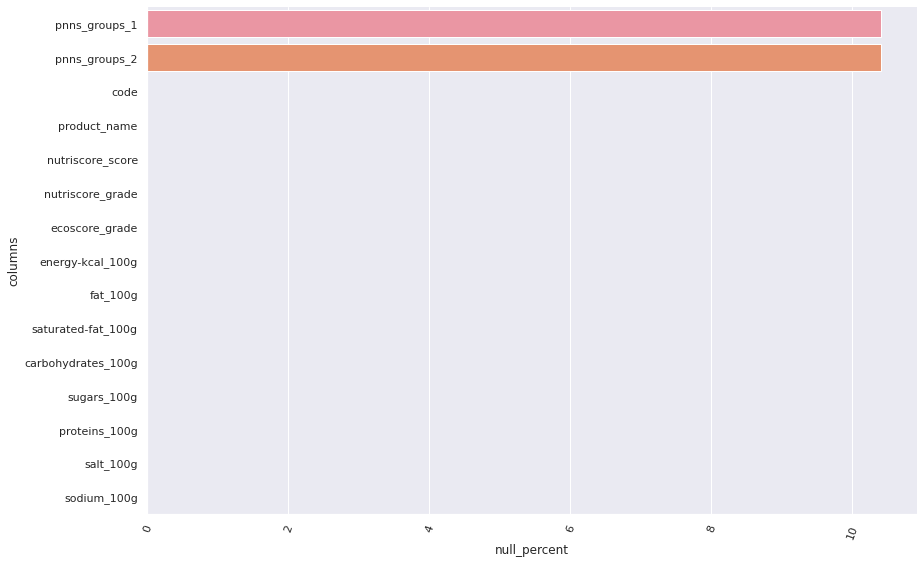

In [55]:
show_nulls(sm_df.loc[sm_df[num_cols].isna().any(1) == False])

In [56]:
# https://pbpython.com/categorical-encoding.html
# https://stackoverflow.com/questions/52059309/convert-categorical-codes-to-categorical-values

In [57]:
sm_df['pnns_groups_1'] = sm_df['pnns_groups_1'].astype('category')
sm_df.dtypes

code                    object
product_name            object
nutriscore_score       float64
nutriscore_grade        object
pnns_groups_1         category
pnns_groups_2           object
ecoscore_grade          object
energy-kcal_100g       float64
fat_100g               float64
saturated-fat_100g     float64
carbohydrates_100g     float64
sugars_100g            float64
proteins_100g          float64
salt_100g              float64
sodium_100g            float64
dtype: object

In [58]:
sm_df['pnns_groups_1_cat'] = sm_df['pnns_groups_1'].cat.codes
sm_df.head()

,code,product_name,nutriscore_score,nutriscore_grade,pnns_groups_1,pnns_groups_2,ecoscore_grade,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g,pnns_groups_1_cat
0,000000001231,Rillettes de sanglier au Chouchen,21.0,e,Salty snacks,Salty and fatty products,unknown,325.0,29.00,11.000,0.000,0.000,16.00,1.60,0.640,8
1,000000001576,Pur jus de pomme,0.0,b,Beverages,Fruit juices,c,221.0,0.50,0.100,0.010,0.010,0.50,0.01,0.004,1
2,000000002218,Rillettes de canard au foie gras,14.0,d,Salty snacks,Salty and fatty products,e,25.0,42.75,17.275,0.475,0.075,13.05,1.10,0.440,8
3,00000006,Riz au lait,4.0,c,Milk and dairy products,Dairy desserts,b,150.0,5.30,3.400,22.000,13.000,3.30,0.12,0.048,7
4,00000038,Pizza prosciutto,5.0,c,Composite foods,Pizza pies and quiches,unknown,197.0,4.70,2.900,25.000,2.100,11.00,1.50,0.600,3


In [59]:
sm_df['pnns_groups_1_cat'].replace(10, np.nan, inplace=True)
sm_df.head()

,code,product_name,nutriscore_score,nutriscore_grade,pnns_groups_1,pnns_groups_2,ecoscore_grade,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g,pnns_groups_1_cat
0,000000001231,Rillettes de sanglier au Chouchen,21.0,e,Salty snacks,Salty and fatty products,unknown,325.0,29.00,11.000,0.000,0.000,16.00,1.60,0.640,8
1,000000001576,Pur jus de pomme,0.0,b,Beverages,Fruit juices,c,221.0,0.50,0.100,0.010,0.010,0.50,0.01,0.004,1
2,000000002218,Rillettes de canard au foie gras,14.0,d,Salty snacks,Salty and fatty products,e,25.0,42.75,17.275,0.475,0.075,13.05,1.10,0.440,8
3,00000006,Riz au lait,4.0,c,Milk and dairy products,Dairy desserts,b,150.0,5.30,3.400,22.000,13.000,3.30,0.12,0.048,7
4,00000038,Pizza prosciutto,5.0,c,Composite foods,Pizza pies and quiches,unknown,197.0,4.70,2.900,25.000,2.100,11.00,1.50,0.600,3


In [60]:
pnns1_dict = dict(enumerate(sm_df['pnns_groups_1'].cat.categories))
pnns1_dict

{0: 'Alcoholic beverages',
 1: 'Beverages',
 2: 'Cereals and potatoes',
 3: 'Composite foods',
 4: 'Fat and sauces',
 5: 'Fish Meat Eggs',
 6: 'Fruits and vegetables',
 7: 'Milk and dairy products',
 8: 'Salty snacks',
 9: 'Sugary snacks'}

In [61]:
sm_df['pnns_groups_2'] = sm_df['pnns_groups_2'].astype('category')
sm_df['pnns_groups_2_cat'] = sm_df['pnns_groups_2'].cat.codes
sm_df['pnns_groups_2_cat'].replace(39, np.nan, inplace=True)
sm_df.head()

,code,product_name,nutriscore_score,nutriscore_grade,pnns_groups_1,pnns_groups_2,ecoscore_grade,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g,pnns_groups_1_cat,pnns_groups_2_cat
0,000000001231,Rillettes de sanglier au Chouchen,21.0,e,Salty snacks,Salty and fatty products,unknown,325.0,29.00,11.000,0.000,0.000,16.00,1.60,0.640,8,30
1,000000001576,Pur jus de pomme,0.0,b,Beverages,Fruit juices,c,221.0,0.50,0.100,0.010,0.010,0.50,0.01,0.004,1,15
2,000000002218,Rillettes de canard au foie gras,14.0,d,Salty snacks,Salty and fatty products,e,25.0,42.75,17.275,0.475,0.075,13.05,1.10,0.440,8,30
3,00000006,Riz au lait,4.0,c,Milk and dairy products,Dairy desserts,b,150.0,5.30,3.400,22.000,13.000,3.30,0.12,0.048,7,9
4,00000038,Pizza prosciutto,5.0,c,Composite foods,Pizza pies and quiches,unknown,197.0,4.70,2.900,25.000,2.100,11.00,1.50,0.600,3,26


In [62]:
pnns2_dict = dict(enumerate(sm_df['pnns_groups_2'].cat.categories))
pnns2_dict

{0: 'Alcoholic beverages',
 1: 'Appetizers',
 2: 'Artificially sweetened beverages',
 3: 'Biscuits and cakes',
 4: 'Bread',
 5: 'Breakfast cereals',
 6: 'Cereals',
 7: 'Cheese',
 8: 'Chocolate products',
 9: 'Dairy desserts',
 10: 'Dressings and sauces',
 11: 'Dried fruits',
 12: 'Eggs',
 13: 'Fats',
 14: 'Fish and seafood',
 15: 'Fruit juices',
 16: 'Fruit nectars',
 17: 'Fruits',
 18: 'Ice cream',
 19: 'Legumes',
 20: 'Meat',
 21: 'Milk and yogurt',
 22: 'Nuts',
 23: 'Offals',
 24: 'One-dish meals',
 25: 'Pastries',
 26: 'Pizza pies and quiches',
 27: 'Plant-based milk substitutes',
 28: 'Potatoes',
 29: 'Processed meat',
 30: 'Salty and fatty products',
 31: 'Sandwiches',
 32: 'Soups',
 33: 'Sweetened beverages',
 34: 'Sweets',
 35: 'Teas and herbal teas and coffees',
 36: 'Unsweetened beverages',
 37: 'Vegetables',
 38: 'Waters and flavored waters'}

### knn inputing

In [63]:
sm_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35707 entries, 0 to 35706
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   code                35707 non-null  object  
 1   product_name        35707 non-null  object  
 2   nutriscore_score    35707 non-null  float64 
 3   nutriscore_grade    35707 non-null  object  
 4   pnns_groups_1       32065 non-null  category
 5   pnns_groups_2       32065 non-null  category
 6   ecoscore_grade      35706 non-null  object  
 7   energy-kcal_100g    34946 non-null  float64 
 8   fat_100g            35087 non-null  float64 
 9   saturated-fat_100g  35644 non-null  float64 
 10  carbohydrates_100g  35608 non-null  float64 
 11  sugars_100g         35615 non-null  float64 
 12  proteins_100g       35650 non-null  float64 
 13  salt_100g           35639 non-null  float64 
 14  sodium_100g         35644 non-null  float64 
 15  pnns_groups_1_cat   35707 non-null  

In [64]:
num_cols_plus_cats = sm_df.columns[sm_df.dtypes == 'float64']
num_cols_plus_cats

Index(['nutriscore_score', 'energy-kcal_100g', 'fat_100g',
       'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g',
       'proteins_100g', 'salt_100g', 'sodium_100g'],
      dtype='object')

In [65]:
sm_df[num_cols_plus_cats].loc[sm_df[num_cols].isna().any(1) == False]

/tmp/ipykernel_5461/890951202.py:1: FutureWarning: In a future version of pandas all arguments of DataFrame.any and Series.any will be keyword-only.
  sm_df[num_cols_plus_cats].loc[sm_df[num_cols].isna().any(1) == False]


,nutriscore_score,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g
0,21.0,325.0,29.00,11.000,0.000,0.000,16.00,1.60,0.640
1,0.0,221.0,0.50,0.100,0.010,0.010,0.50,0.01,0.004
2,14.0,25.0,42.75,17.275,0.475,0.075,13.05,1.10,0.440
3,4.0,150.0,5.30,3.400,22.000,13.000,3.30,0.12,0.048
4,5.0,197.0,4.70,2.900,25.000,2.100,11.00,1.50,0.600
...,...,...,...,...,...,...,...,...,...
35702,10.0,185.0,0.00,0.000,45.000,45.000,0.80,0.08,0.032
35703,-1.0,35.0,1.00,0.000,4.000,0.000,2.00,0.07,0.028
35704,10.0,246.0,18.50,12.300,1.000,1.000,18.90,0.60,0.240
35705,1.0,1.0,0.00,0.000,0.300,0.000,0.20,0.00,0.000


In [66]:
imputer = KNNImputer(n_neighbors=2)

In [67]:
imputer.fit_transform(sm_df[num_cols_plus_cats].loc[sm_df[num_cols].isna().any(1) == False])

/tmp/ipykernel_5461/55618228.py:1: FutureWarning: In a future version of pandas all arguments of DataFrame.any and Series.any will be keyword-only.
  imputer.fit_transform(sm_df[num_cols_plus_cats].loc[sm_df[num_cols].isna().any(1) == False])


array([[2.100e+01, 3.250e+02, 2.900e+01, ..., 1.600e+01, 1.600e+00,
        6.400e-01],
       [0.000e+00, 2.210e+02, 5.000e-01, ..., 5.000e-01, 1.000e-02,
        4.000e-03],
       [1.400e+01, 2.500e+01, 4.275e+01, ..., 1.305e+01, 1.100e+00,
        4.400e-01],
       ...,
       [1.000e+01, 2.460e+02, 1.850e+01, ..., 1.890e+01, 6.000e-01,
        2.400e-01],
       [1.000e+00, 1.000e+00, 0.000e+00, ..., 2.000e-01, 0.000e+00,
        0.000e+00],
       [7.000e+00, 1.500e+02, 6.100e+00, ..., 2.900e+00, 8.000e-02,
        3.200e-02]])

In [68]:
#imputer.fit_transform(sm_df[num_cols])

In [69]:
sm_df.head()

,code,product_name,nutriscore_score,nutriscore_grade,pnns_groups_1,pnns_groups_2,ecoscore_grade,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g,pnns_groups_1_cat,pnns_groups_2_cat
0,000000001231,Rillettes de sanglier au Chouchen,21.0,e,Salty snacks,Salty and fatty products,unknown,325.0,29.00,11.000,0.000,0.000,16.00,1.60,0.640,8,30
1,000000001576,Pur jus de pomme,0.0,b,Beverages,Fruit juices,c,221.0,0.50,0.100,0.010,0.010,0.50,0.01,0.004,1,15
2,000000002218,Rillettes de canard au foie gras,14.0,d,Salty snacks,Salty and fatty products,e,25.0,42.75,17.275,0.475,0.075,13.05,1.10,0.440,8,30
3,00000006,Riz au lait,4.0,c,Milk and dairy products,Dairy desserts,b,150.0,5.30,3.400,22.000,13.000,3.30,0.12,0.048,7,9
4,00000038,Pizza prosciutto,5.0,c,Composite foods,Pizza pies and quiches,unknown,197.0,4.70,2.900,25.000,2.100,11.00,1.50,0.600,3,26


                               columns  count  null_percent
pnns_groups_1            pnns_groups_1   3642          10.2
pnns_groups_2            pnns_groups_2   3642          10.2
energy-kcal_100g      energy-kcal_100g    761           2.1
fat_100g                      fat_100g    620           1.7
sugars_100g                sugars_100g     92           0.3
carbohydrates_100g  carbohydrates_100g     99           0.3
sodium_100g                sodium_100g     63           0.2
salt_100g                    salt_100g     68           0.2
proteins_100g            proteins_100g     57           0.2
saturated-fat_100g  saturated-fat_100g     63           0.2
pnns_groups_1_cat    pnns_groups_1_cat      0           0.0
code                              code      0           0.0
product_name              product_name      0           0.0
ecoscore_grade          ecoscore_grade      1           0.0
nutriscore_grade      nutriscore_grade      0           0.0
nutriscore_score      nutriscore_score  

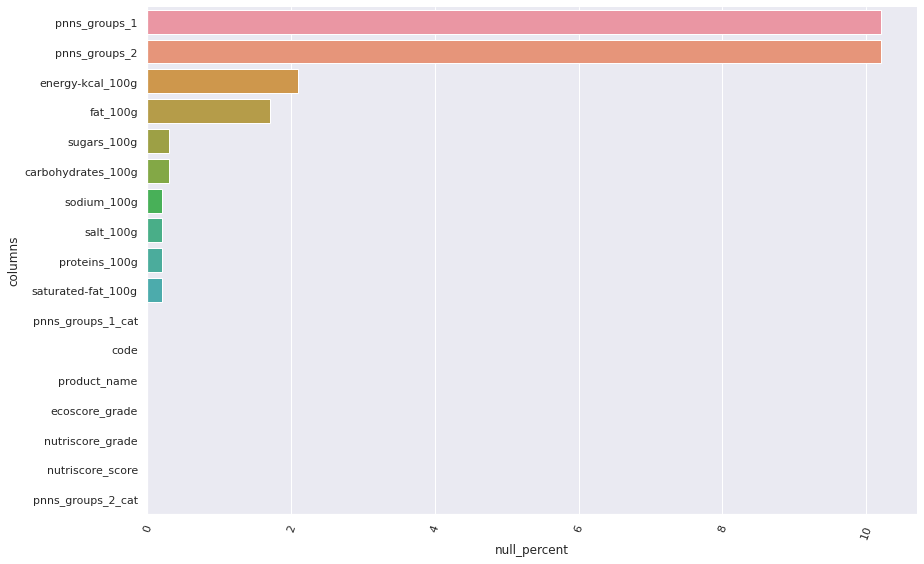

In [70]:
show_nulls(sm_df)

In [88]:
sm_df[['code', 'product_name']].head(10)

,code,product_name
0,000000001231,Rillettes de sanglier au Chouchen
1,000000001576,Pur jus de pomme
2,000000002218,Rillettes de canard au foie gras
3,00000006,Riz au lait
4,00000038,Pizza prosciutto
5,0000005013,Organic pesto alla genovese
6,0000005020,Pesto Rosso
7,00000147,Pan
8,0000020928605,Foie gras de canard entier du sud-ouest
9,00000789,Cordon bleu de volaille bio


In [90]:
sm_df[['code', 'product_name']].nunique()

code            35707
product_name    22762
dtype: int64

In [ ]:
# => enlever code / product_name / pnns_groups_1 / pnns_groups_2

### Mapping back cat values

In [71]:
sm_df['pnns_groups_1'] = sm_df['pnns_groups_1_cat'].map(pnns1_dict)
sm_df['pnns_groups_2'] = sm_df['pnns_groups_2_cat'].map(pnns2_dict)
sm_df.drop(columns=['pnns_groups_1_cat', 'pnns_groups_2_cat'], inplace=True)
sm_df.head()

,code,product_name,nutriscore_score,nutriscore_grade,pnns_groups_1,pnns_groups_2,ecoscore_grade,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g
0,000000001231,Rillettes de sanglier au Chouchen,21.0,e,Salty snacks,Salty and fatty products,unknown,325.0,29.00,11.000,0.000,0.000,16.00,1.60,0.640
1,000000001576,Pur jus de pomme,0.0,b,Beverages,Fruit juices,c,221.0,0.50,0.100,0.010,0.010,0.50,0.01,0.004
2,000000002218,Rillettes de canard au foie gras,14.0,d,Salty snacks,Salty and fatty products,e,25.0,42.75,17.275,0.475,0.075,13.05,1.10,0.440
3,00000006,Riz au lait,4.0,c,Milk and dairy products,Dairy desserts,b,150.0,5.30,3.400,22.000,13.000,3.30,0.12,0.048
4,00000038,Pizza prosciutto,5.0,c,Composite foods,Pizza pies and quiches,unknown,197.0,4.70,2.900,25.000,2.100,11.00,1.50,0.600


In [72]:
# drop cat numerical cols

In [ ]:
# univariée (histos) / bivariée (axes ++ / confusion matrix)

In [ ]:
#from sklearn.preprocessing import OneHotEncoder

#ohe = OneHotEncoder(sparse = False) #instanciate encoder
#ohe.fit(top_df[['pnns_groups_1']]) # fit encoder
#pnn1_encoded = ohe.transform(top_df[['pnns_groups_1']]) # encode pnn1
#

## numerical values

In [73]:
### appliquer imputer différentes strategies (check distribution) avec un groupby categories
### iterative imputer / estimation du choix d'imputer selon la distribution (mean/median/most frequent...)


### main_cats : fat / salt => mean input

In [74]:
#groupby pnns_groups_1, mean, remplir avec mean / categorie
#list1 = ["fat_100g", "salt_100g"]
main_cats

['fat_100g', 'salt_100g']

In [75]:
#main_cats_grp = main_cats.append('pnns_group_1')
#main_cats_grp

In [76]:
#main_cats_grp = ['fat_100g', 'salt_100g', 'pnns_group_1']
#main_cats_grp

In [77]:
# sm_df[[c for c in df.columns if c in main_cats]].head()

In [78]:
sm_df.filter(main_cats).head()

,fat_100g,salt_100g
0,29.00,1.60
1,0.50,0.01
2,42.75,1.10
3,5.30,0.12
4,4.70,1.50


In [79]:
sm_df_groupby = sm_df.groupby(by='pnns_groups_1')

In [80]:
sm_df_groupby.mean()

/tmp/ipykernel_5461/759746573.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sm_df_groupby.mean()


,nutriscore_score,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g
pnns_groups_1,,,,,,,,,
Alcoholic beverages,5.333333,19.033333,0.233333,0.100000,2.700000,2.500000,0.233333,0.070000,0.028000
Beverages,5.801766,41.065835,0.729726,0.300276,8.090392,7.002033,0.529250,0.278033,0.144875
Cereals and potatoes,2.961575,296.641018,5.909992,1.422141,46.393927,2.512732,9.962445,0.798703,0.319481
Composite foods,5.098698,172.490696,8.295963,2.842547,14.218842,2.325641,7.809610,1.037694,0.415078
Fat and sauces,11.280680,297.024197,23.240833,7.201190,8.065116,5.585292,2.247279,1.922780,0.785008
Fish Meat Eggs,9.160279,212.081174,12.721389,4.409235,2.118093,0.679266,19.404503,1.834085,0.739789
Fruits and vegetables,-0.890644,89.868088,2.132838,0.543577,12.546922,7.602609,2.401016,0.731421,0.292568
Milk and dairy products,11.785018,296.205554,23.096817,15.324173,4.185955,3.085208,18.189678,1.200528,0.489242
Salty snacks,13.509857,376.594203,31.469245,8.967984,11.860266,1.647096,9.220256,1.569842,0.627937


In [81]:
sm_df.columns

Index(['code', 'product_name', 'nutriscore_score', 'nutriscore_grade',
       'pnns_groups_1', 'pnns_groups_2', 'ecoscore_grade', 'energy-kcal_100g',
       'fat_100g', 'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g',
       'proteins_100g', 'salt_100g', 'sodium_100g'],
      dtype='object')

In [82]:
sm_df_groupby[main_cats].mean()

,fat_100g,salt_100g
pnns_groups_1,,
Alcoholic beverages,0.233333,0.070000
Beverages,0.729726,0.278033
Cereals and potatoes,5.909992,0.798703
Composite foods,8.295963,1.037694
Fat and sauces,23.240833,1.922780
Fish Meat Eggs,12.721389,1.834085
Fruits and vegetables,2.132838,0.731421
Milk and dairy products,23.096817,1.200528
Salty snacks,31.469245,1.569842


In [83]:
sm_df_groupby[main_cats].count()

,fat_100g,salt_100g
pnns_groups_1,,
Alcoholic beverages,3,3
Beverages,1192,1184
Cereals and potatoes,2051,2082
Composite foods,2918,2918
Fat and sauces,1944,2467
Fish Meat Eggs,12757,12757
Fruits and vegetables,1645,1646
Milk and dairy products,4819,4818
Salty snacks,2586,2587


In [84]:
# https://pandas.pydata.org/docs/user_guide/groupby.html

sm_df[main_cats] = sm_df_groupby[main_cats].transform(lambda x: x.fillna(x.mean()))

In [85]:
sm_df.isna().sum()

code                     0
product_name             0
nutriscore_score         0
nutriscore_grade         0
pnns_groups_1         3642
pnns_groups_2         3642
ecoscore_grade           1
energy-kcal_100g       761
fat_100g              3642
saturated-fat_100g      63
carbohydrates_100g      99
sugars_100g             92
proteins_100g           57
salt_100g             3642
sodium_100g             63
dtype: int64

In [86]:
sm_df_gr_transf = sm_df_groupby[main_cats].transform(lambda x: x.fillna(x.mean()))
sm_df_gr_transf

,fat_100g,salt_100g
0,29.00,1.60
1,0.50,0.01
2,42.75,1.10
3,5.30,0.12
4,4.70,1.50
...,...,...
35702,0.00,0.08
35703,NaN,NaN
35704,18.50,0.60
35705,NaN,NaN


In [87]:
grouped.transform(lambda x: x.fillna(inplace=False))

NameError: name 'grouped' is not defined

In [ ]:
sm_df.isna().sum()

In [ ]:
sm_df_groupby[main_cats]

In [ ]:
## faire fonction et apply par ligne ou boucler sur données uniques

In [ ]:
sm_df_main_mean = sm_df_groupby[main_cats].mean()
sm_df_main_mean

In [ ]:
sm_df.head()

In [ ]:
sm_df_main_mean['fat_100g']

In [ ]:
import math

def fill_grp_fat(row):
    if math.isnan(row['fat_100g']):
        cat = row['pnns_groups_1']
        print(cat)
        return sm_df_main_mean['fat_100g'][cat]
    else:
        return row['fat_100g']

In [ ]:
#sm_df['pnns_groups_1'].value_counts()

In [ ]:
sm_df['fat_100g'] = sm_df.apply(lambda x : fill_grp_fat(x), axis=1)

In [ ]:
## utiliser index (str) de sm_df_groupby

In [ ]:
#sm_df.filter(main_cats_grp).head()

### compl_cats : sat_fat / sodium => linearRegression

In [ ]:
# IterativeImputer avec estimator=LinearRegression()
#list2 = ["saturated-fat_100g", "sodium_100g"] 
complementary_cats

In [ ]:
sm_df.filter(complementary_cats).head()

In [ ]:
#sm_df_groupby.median().columns

In [ ]:
#sm_df_groupby.median()

In [ ]:
sm_df_groupby[complementary_cats].median()

### final_cats => 

In [ ]:
final_cats

In [30]:
#Reste des variables contenant des valeurs vides (sans list1, list2,  pnns_groups_1, pnns_groups_2) : 
# remplir soit avec la moyenne soit avec la mediane, en fonction de la distribution 
#- remplir avec la valeur la plus fréquente


In [ ]:
#imp_med = SimpleImputer(missing_values=np.nan, strategy='median')

###sm_df[all_num_cols] = imp_med.fit_transform(sm_df[all_num_cols])